In [1]:
import pandas as pd
import numpy as np

In [ ]:
DNA_data = pd.read_csv('/Users/khj/Desktop/Work/01_In-progress/01.DRBP/data/DRBP_result_analysis/analysis_raw_data/VAT score/spline_z_score_normalized/z_score/DBP_spline_zscore_normalized_251103.csv')
RNA_data = pd.read_csv('/Users/khj/Desktop/Work/01_In-progress/01.DRBP/data/DRBP_result_analysis/analysis_raw_data/VAT score/spline_z_score_normalized/z_score/RBP_spline_zscore_normalized_251103.csv')
RNA_data

In [ ]:
interpro_consensus = pd.read_csv('/Users/khj/Desktop/Work/01_In-progress/01.DRBP/data/DRBP_result_analysis/interpro_consensus/human_interpro_consensus.csv')
interpro_consensus

In [ ]:
import pandas as pd
import numpy as np

# A: >ENSP... 컬럼들이 있고, 행 인덱스는 포지션(0,1,2,...)라고 가정
# B: 컬럼 ['ENSP_ID', 'consensus_start', 'consensus_end'] 가정

def map_to_A_column(ensp_id: str, A_columns: set):
    """B의 ENSP_ID를 A의 컬럼명으로 매핑(> 유무 보정)"""
    if ensp_id in A_columns:
        return ensp_id
    if f">{ensp_id}" in A_columns:
        return f">{ensp_id}"
    if ensp_id.startswith('>') and ensp_id[1:] in A_columns:
        return ensp_id[1:]
    return np.nan  # 매칭 실패 시 NaN

def attach_means(A: pd.DataFrame, B: pd.DataFrame) -> pd.DataFrame:
    B = B.copy()

    # 1) ENSP_ID -> A 컬럼명 매핑
    A_cols = set(A.columns)
    B['A_col'] = B['ENSP_ID'].astype(str).map(lambda x: map_to_A_column(x, A_cols))

    # 2) 컬럼 전체 평균 (col-wise mean)
    col_means = A.mean(axis=0, skipna=True)
    B['mean_score_all'] = B['A_col'].map(col_means)

    # 3) 구간 평균 (start~end 포함)
    n_rows = len(A)

    def range_mean(row):
        col = row['A_col']
        if pd.isna(col) or col not in A.columns:
            return np.nan
        # 숫자화 & 정리
        try:
            s = int(row['consensus_start'])
            e = int(row['consensus_end'])
        except Exception:
            return np.nan
        if s > e:
            s, e = e, s
        # 인덱스 클리핑 (inclusive)
        s = max(0, s)
        e = min(n_rows - 1, e)
        if s > e:
            return np.nan
        return float(A[col].iloc[s:e+1].mean())

    B['mean_score_range'] = B.apply(range_mean, axis=1)

    return B

# 사용 예시
DNA_with_means = attach_means(RNA_data, interpro_consensus)
DNA_with_means

In [ ]:
# 사용 예시
DNA_with_means = attach_means(DNA_data, interpro_consensus)
DNA_with_means

In [ ]:
DNA_with_means = DNA_with_means[['ENSP_ID','Interpro_ID','consensus_start', 'consensus_end', 'mean_score_range']]
DNA_with_means

In [ ]:
DNA_with_means.drop_duplicates(subset='Interpro_ID')

In [ ]:
RNA_with_means = attach_means(RNA_data, interpro_consensus)
RNA_with_means

In [ ]:
RNA_with_means = RNA_with_means[['ENSP_ID','Interpro_ID','consensus_start', 'consensus_end', 'mean_score_range']]
RNA_with_means

In [ ]:
RNA_with_means.drop_duplicates(subset='Interpro_ID')

In [ ]:
DNA_with_means.to_csv('/Users/khj/Desktop/Work/01_In-progress/01.DRBP/data/DRBP_result_analysis/IPR_VATP_score/DBP_spline_z_score_normalized_with_means.csv', index=False)
RNA_with_means.to_csv('/Users/khj/Desktop/Work/01_In-progress/01.DRBP/data/DRBP_result_analysis/IPR_VATP_score/RBP_spline_z_score_normalized_with_means.csv', index=False)

In [2]:
#DNA_with_means = pd.read_csv('/Users/khj/Desktop/Work/01_In-progress/01.DRBP/data/DRBP_result_analysis/IPR_VATP_score/DBP_spline_z_score_normalized_with_means.csv')
DNA_with_means = pd.read_csv('/Users/khj/Desktop/Work/01_In-progress/01.DRBP/data/DRBP_result_analysis/IPR_VATP_score/RBP_spline_z_score_normalized_with_means.csv')
DNA_with_means

,ENSP_ID,Interpro_ID,consensus_start,consensus_end,mean_score_range
0,ENSP00000000233,IPR005225,16,138,0.968173
1,ENSP00000000233,IPR006689,74,99,1.413712
2,ENSP00000000233,IPR024156,1,174,0.833246
3,ENSP00000000233,IPR027417,14,177,0.623367
4,ENSP00000000233,IPR045872,18,176,0.633761
...,...,...,...,...,...
117998,ENSP00000498205,IPR012340,534,615,0.025123
117999,ENSP00000498205,IPR012340,631,710,0.143376
118000,ENSP00000498205,IPR012340,719,801,1.886651
118001,ENSP00000498205,IPR045209,1,982,0.148168


In [3]:
DNA_GO_IPR = pd.read_csv('/Users/khj/Desktop/Work/01_In-progress/01.DRBP/data/DRBP_result_analysis/Binding_info/Go_slim_agr/GO_slim_RBP_IPR_filtered.csv')
DNA_GO_IPR

,11,12,13,GO_list,GO:0019538_protein_metabolic_process_descendants,GO:0030246_carbohydrate_binding_descendants,GO:0012501_programmed_cell_death_descendants,GO:0051234_establishment_of_localization_descendants,GO:0005856_cytoskeleton_descendants,GO:0030154_cell_differentiation_descendants,...,GO:0005215_transporter_activity_descendants,GO:0046872_metal_ion_binding_descendants,GO:0006259_DNA_metabolic_process_descendants,GO:0005829_cytosol_descendants,GO:0042995_cell_projection_descendants,GO:0005739_mitochondrion_descendants,GO:0030234_enzyme_regulator_activity_descendants,GO:0005634_nucleus_descendants,GO:0032502_developmental_process_descendants,GO:0005794_Golgi_apparatus_descendants
0,IPR000504,RNA recognition motif domain,GO:0003723(InterPro),['GO:0003723'],0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,IPR036053,PABC (PABP) domain,GO:0003723(InterPro),['GO:0003723'],0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,IPR002004,Polyadenylate-binding protein/Hyperplastic dis...,GO:0003723(InterPro),['GO:0003723'],0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,IPR051373,Lin-28 homolog RNA-binding protein,GO:0003729(PANTHER)|GO:0005634(PANTHER)|GO:000...,"['GO:0003729', 'GO:0005634', 'GO:0005737', 'GO...",0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,IPR000892,Small ribosomal subunit protein eS26,GO:0003729(PANTHER)|GO:0003735(PANTHER)|GO:000...,"['GO:0003729', 'GO:0003735', 'GO:0003735', 'GO...",1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,IPR020119,"Pseudouridine synthase TruD, conserved site",GO:0001522(InterPro)|GO:0003723(InterPro)|GO:0...,"['GO:0001522', 'GO:0003723', 'GO:0009451', 'GO...",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
431,IPR052652,Telomerase Complex Component,GO:0000722(PANTHER)|GO:0003720(PANTHER)|GO:000...,"['GO:0000722', 'GO:0003720', 'GO:0005697', 'GO...",0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
432,IPR008383,Apoptosis inhibitory 5,GO:0003723(PANTHER)|GO:0005634(PANTHER)|GO:004...,"['GO:0003723', 'GO:0005634', 'GO:0043066']",0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
433,IPR018268,"Small ribosomal subunit protein uS10, conserve...",GO:0003723(InterPro)|GO:0003735(InterPro)|GO:0...,"['GO:0003723', 'GO:0003735', 'GO:0005840', 'GO...",1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
DNA_with_means_GO_IPR = DNA_with_means[DNA_with_means['Interpro_ID'].isin(DNA_GO_IPR['11'])]
DNA_with_means_GO_IPR

,ENSP_ID,Interpro_ID,consensus_start,consensus_end,mean_score_range
649,ENSP00000084795,IPR000039,3,189,0.495286
727,ENSP00000156471,IPR045055,450,982,0.676809
1238,ENSP00000198939,IPR000061,15,57,2.747430
1242,ENSP00000198939,IPR035967,4,67,1.487443
1293,ENSP00000199814,IPR000504,234,298,0.652659
...,...,...,...,...,...
117953,ENSP00000498157,IPR002415,182,192,1.804225
117954,ENSP00000498157,IPR002415,226,238,3.347177
117961,ENSP00000498157,IPR050257,151,268,2.163446
117975,ENSP00000498177,IPR041988,52,106,1.988236


In [5]:
DNA_with_means_result_unique = DNA_with_means_GO_IPR.groupby('ENSP_ID')['Interpro_ID'].count().reset_index(name='IPR_count_per_protein')
DNA_with_means_result_score = DNA_with_means_GO_IPR.groupby('ENSP_ID')['mean_score_range'].mean().reset_index(name='IPR_VAT_score_per_protein')
DNA_with_means_unique_merge = DNA_with_means_GO_IPR.merge(DNA_with_means_result_unique, on='ENSP_ID', how='left')
DNA_with_means_unique_score_merge = DNA_with_means_unique_merge.merge(DNA_with_means_result_score, on='ENSP_ID', how='left')
DNA_with_means_unique_score_merge

,ENSP_ID,Interpro_ID,consensus_start,consensus_end,mean_score_range,IPR_count_per_protein,IPR_VAT_score_per_protein
0,ENSP00000084795,IPR000039,3,189,0.495286,1,0.495286
1,ENSP00000156471,IPR045055,450,982,0.676809,1,0.676809
2,ENSP00000198939,IPR000061,15,57,2.747430,2,2.117436
3,ENSP00000198939,IPR035967,4,67,1.487443,2,2.117436
4,ENSP00000199814,IPR000504,234,298,0.652659,2,0.730341
...,...,...,...,...,...,...,...
1408,ENSP00000498157,IPR002415,182,192,1.804225,4,2.285629
1409,ENSP00000498157,IPR002415,226,238,3.347177,4,2.285629
1410,ENSP00000498157,IPR050257,151,268,2.163446,4,2.285629
1411,ENSP00000498177,IPR041988,52,106,1.988236,1,1.988236


In [6]:
DNA_with_means_unique_score_merge['consensus_length'] = DNA_with_means_unique_score_merge['consensus_end'] - DNA_with_means_unique_score_merge['consensus_start'] + 1
#DNA_with_means_unique_score_merge_drop_dup_byENSPID = DNA_with_means_unique_score_merge.drop_duplicates(subset='ENSP_ID')
DNA_with_means_unique_score_merge

,ENSP_ID,Interpro_ID,consensus_start,consensus_end,mean_score_range,IPR_count_per_protein,IPR_VAT_score_per_protein,consensus_length
0,ENSP00000084795,IPR000039,3,189,0.495286,1,0.495286,187
1,ENSP00000156471,IPR045055,450,982,0.676809,1,0.676809,533
2,ENSP00000198939,IPR000061,15,57,2.747430,2,2.117436,43
3,ENSP00000198939,IPR035967,4,67,1.487443,2,2.117436,64
4,ENSP00000199814,IPR000504,234,298,0.652659,2,0.730341,65
...,...,...,...,...,...,...,...,...
1408,ENSP00000498157,IPR002415,182,192,1.804225,4,2.285629,11
1409,ENSP00000498157,IPR002415,226,238,3.347177,4,2.285629,13
1410,ENSP00000498157,IPR050257,151,268,2.163446,4,2.285629,118
1411,ENSP00000498177,IPR041988,52,106,1.988236,1,1.988236,55


In [7]:
prot_seq = pd.read_csv('/Users/khj/Desktop/Work/01_In-progress/01.DRBP/data/raw_data/DRBP_uniprot_mapping.csv')
prot_seq = prot_seq.drop_duplicates(subset='ENSP_ID')
prot_seq['Seq_length'] = prot_seq['Sequence'].str.len().astype(int)
prot_seq = prot_seq[['ENSP_ID','Seq_length']]
prot_seq['ENSP_ID'] = prot_seq['ENSP_ID'].str.replace('>', '', regex=False)
prot_seq   

,ENSP_ID,Seq_length
0,ENSP00000345702,347
2,ENSP00000317128,1925
4,ENSP00000383042,876
6,ENSP00000368332,562
8,ENSP00000006015,313
...,...,...
36428,ENSP00000310632,359
36430,ENSP00000493167,317
36432,ENSP00000314295,255
36434,ENSP00000384223,883


In [8]:
DNA_with_means_unique_score_merge_final = DNA_with_means_unique_score_merge.merge(prot_seq, on='ENSP_ID', how='left')
DNA_with_means_unique_score_merge_final['IPR_proportion'] = DNA_with_means_unique_score_merge_final['consensus_length'] / DNA_with_means_unique_score_merge_final['Seq_length']
DNA_with_means_unique_score_merge_final

,ENSP_ID,Interpro_ID,consensus_start,consensus_end,mean_score_range,IPR_count_per_protein,IPR_VAT_score_per_protein,consensus_length,Seq_length,IPR_proportion
0,ENSP00000084795,IPR000039,3,189,0.495286,1,0.495286,187,189.0,0.989418
1,ENSP00000156471,IPR045055,450,982,0.676809,1,0.676809,533,1485.0,0.358923
2,ENSP00000198939,IPR000061,15,57,2.747430,2,2.117436,43,927.0,0.046386
3,ENSP00000198939,IPR035967,4,67,1.487443,2,2.117436,64,927.0,0.069040
4,ENSP00000199814,IPR000504,234,298,0.652659,2,0.730341,65,420.0,0.154762
...,...,...,...,...,...,...,...,...,...,...
1408,ENSP00000498157,IPR002415,182,192,1.804225,4,2.285629,11,272.0,0.040441
1409,ENSP00000498157,IPR002415,226,238,3.347177,4,2.285629,13,272.0,0.047794
1410,ENSP00000498157,IPR050257,151,268,2.163446,4,2.285629,118,272.0,0.433824
1411,ENSP00000498177,IPR041988,52,106,1.988236,1,1.988236,55,145.0,0.379310


In [9]:
bins = [-np.inf, 1, 2, 3, 4, 5, np.inf]
labels = ['≤1', '2', '3', '4', '5', '≥6']

DNA_with_means_unique_score_merge_final['IPR_count_bin'] = pd.cut(
    DNA_with_means_unique_score_merge_final['IPR_count_per_protein'],
    bins=bins,
    labels=labels,
    right=True
)
DNA_with_means_unique_score_merge_final

,ENSP_ID,Interpro_ID,consensus_start,consensus_end,mean_score_range,IPR_count_per_protein,IPR_VAT_score_per_protein,consensus_length,Seq_length,IPR_proportion,IPR_count_bin
0,ENSP00000084795,IPR000039,3,189,0.495286,1,0.495286,187,189.0,0.989418,≤1
1,ENSP00000156471,IPR045055,450,982,0.676809,1,0.676809,533,1485.0,0.358923,≤1
2,ENSP00000198939,IPR000061,15,57,2.747430,2,2.117436,43,927.0,0.046386,2
3,ENSP00000198939,IPR035967,4,67,1.487443,2,2.117436,64,927.0,0.069040,2
4,ENSP00000199814,IPR000504,234,298,0.652659,2,0.730341,65,420.0,0.154762,2
...,...,...,...,...,...,...,...,...,...,...,...
1408,ENSP00000498157,IPR002415,182,192,1.804225,4,2.285629,11,272.0,0.040441,4
1409,ENSP00000498157,IPR002415,226,238,3.347177,4,2.285629,13,272.0,0.047794,4
1410,ENSP00000498157,IPR050257,151,268,2.163446,4,2.285629,118,272.0,0.433824,4
1411,ENSP00000498177,IPR041988,52,106,1.988236,1,1.988236,55,145.0,0.379310,≤1


In [10]:
BP_bind_result = pd.read_csv("/Users/khj/Desktop/Work/01_In-progress/01.DRBP/data/DRBP_result/DRBP_pred_concat.csv")
DBP_bind_result = BP_bind_result[BP_bind_result['RNA pred']==1]
DBP_bind_result_list = list(DBP_bind_result['ID'])
DBP_bind_result_list = [item.replace('>', '') for item in DBP_bind_result_list]
DBP_bind_result_list

['ENSP00000007699',
 'ENSP00000156109',
 'ENSP00000170168',
 'ENSP00000170447',
 'ENSP00000170564',
 'ENSP00000181839',
 'ENSP00000198939',
 'ENSP00000199814',
 'ENSP00000202773',
 'ENSP00000202816',
 'ENSP00000215793',
 'ENSP00000216122',
 'ENSP00000216190',
 'ENSP00000216727',
 'ENSP00000216832',
 'ENSP00000217073',
 'ENSP00000217964',
 'ENSP00000218364',
 'ENSP00000219313',
 'ENSP00000220496',
 'ENSP00000221265',
 'ENSP00000221419',
 'ENSP00000221455',
 'ENSP00000222968',
 'ENSP00000223073',
 'ENSP00000225298',
 'ENSP00000225792',
 'ENSP00000226798',
 'ENSP00000228136',
 'ENSP00000228251',
 'ENSP00000228284',
 'ENSP00000229214',
 'ENSP00000229390',
 'ENSP00000230640',
 'ENSP00000232888',
 'ENSP00000233078',
 'ENSP00000233468',
 'ENSP00000238146',
 'ENSP00000240185',
 'ENSP00000242776',
 'ENSP00000242848',
 'ENSP00000243563',
 'ENSP00000244020',
 'ENSP00000244534',
 'ENSP00000244573',
 'ENSP00000245255',
 'ENSP00000246194',
 'ENSP00000247001',
 'ENSP00000247026',
 'ENSP00000250113',


In [11]:
len(DBP_bind_result_list)

529

In [12]:
18221-len(DBP_bind_result_list)

17692

In [13]:
DNA_with_means_unique_score_merge_final['Binding'] = np.where(
    DNA_with_means_unique_score_merge_final['ENSP_ID'].isin(DBP_bind_result_list),
    'Binding',
    'Not'
)
DNA_with_means_unique_score_merge_final

,ENSP_ID,Interpro_ID,consensus_start,consensus_end,mean_score_range,IPR_count_per_protein,IPR_VAT_score_per_protein,consensus_length,Seq_length,IPR_proportion,IPR_count_bin,Binding
0,ENSP00000084795,IPR000039,3,189,0.495286,1,0.495286,187,189.0,0.989418,≤1,Not
1,ENSP00000156471,IPR045055,450,982,0.676809,1,0.676809,533,1485.0,0.358923,≤1,Not
2,ENSP00000198939,IPR000061,15,57,2.747430,2,2.117436,43,927.0,0.046386,2,Binding
3,ENSP00000198939,IPR035967,4,67,1.487443,2,2.117436,64,927.0,0.069040,2,Binding
4,ENSP00000199814,IPR000504,234,298,0.652659,2,0.730341,65,420.0,0.154762,2,Binding
...,...,...,...,...,...,...,...,...,...,...,...,...
1408,ENSP00000498157,IPR002415,182,192,1.804225,4,2.285629,11,272.0,0.040441,4,Not
1409,ENSP00000498157,IPR002415,226,238,3.347177,4,2.285629,13,272.0,0.047794,4,Not
1410,ENSP00000498157,IPR050257,151,268,2.163446,4,2.285629,118,272.0,0.433824,4,Not
1411,ENSP00000498177,IPR041988,52,106,1.988236,1,1.988236,55,145.0,0.379310,≤1,Not


In [14]:
count_df = (
    DNA_with_means_unique_score_merge_final
    .groupby(['Binding', 'IPR_count_bin'])
    .size()
    .reset_index(name='count')
)

denominator_map = {
    'Binding': 529,
    'Not': 17692
}

count_df['count_proportion'] =  count_df['count'] / count_df['Binding'].map(denominator_map)
count_df

/var/folders/yg/583d6r_n1db_299qvldgw8k00000gn/T/ipykernel_52428/1067055041.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Binding', 'IPR_count_bin'])


,Binding,IPR_count_bin,count,count_proportion
0,Binding,≤1,108,0.204159
1,Binding,2,162,0.306238
2,Binding,3,117,0.221172
3,Binding,4,104,0.196597
4,Binding,5,70,0.132325
5,Binding,≥6,250,0.472590
6,Not,≤1,297,0.016787
7,Not,2,172,0.009722
8,Not,3,54,0.003052
9,Not,4,40,0.002261


/var/folders/yg/583d6r_n1db_299qvldgw8k00000gn/T/ipykernel_52428/301316995.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['IPR_count_bin', 'Binding'])['IPR_proportion']


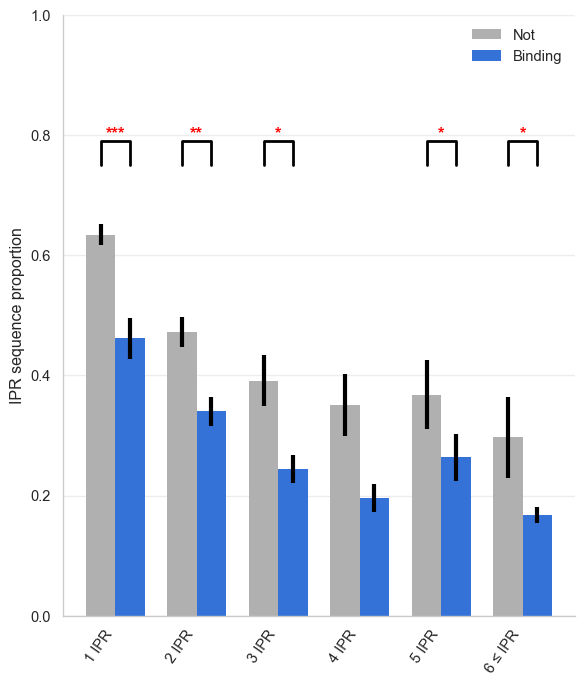

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

df = DNA_with_means_unique_score_merge_final.copy()

# ---- (권장) x축 bin 순서/라벨 ----
order = ['≤1', '2', '3', '4', '5', '≥6']
label_map = {'≤1': '1 IPR', '2': '2 IPR', '3': '3 IPR', '4': '4 IPR', '5': '5 IPR', '≥6': '6 ≤ IPR'}

df['IPR_count_bin'] = pd.Categorical(df['IPR_count_bin'], categories=order, ordered=True)

# ---- 요약 통계 (mean + SEM 또는 STD 선택) ----
# 예시 그림은 보통 SEM을 많이 씁니다. STD를 쓰려면 err_col='std'로 바꾸세요.
summary = (
    df.groupby(['IPR_count_bin', 'Binding'])['IPR_proportion']
      .agg(mean='mean', std='std', n='count')
      .reset_index()
)
summary['sem'] = summary['std'] / np.sqrt(summary['n'])

# ---- 스타일 ----
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
palette = {'Not': '#B0B0B0', 'Binding': '#3472D7'}

fig, ax = plt.subplots(figsize=(6.0, 7.0))  # 예시처럼 세로로 길게

x = np.arange(len(order))
width = 0.36

def get_bar_x(bin_idx, group):
    # Not=왼쪽, Binding=오른쪽
    return x[bin_idx] - width/2 if group == 'Not' else x[bin_idx] + width/2

# ---- 막대 + errorbar (검은색, 두껍게) ----
err_col = 'sem'   # 'std'로 바꾸면 표준편차
for group in ['Not', 'Binding']:
    sub = summary[summary['Binding'] == group].set_index('IPR_count_bin').reindex(order).reset_index()

    xpos = [get_bar_x(i, group) for i in range(len(order))]
    ax.bar(
        xpos,
        sub['mean'].values,
        width=width,
        color=palette[group],
        edgecolor='none',
        zorder=2,
        label=group
    )
    ax.errorbar(
        xpos,
        sub['mean'].values,
        yerr=sub[err_col].values,
        fmt='none',
        ecolor='black',
        elinewidth=3.0,   # 예시처럼 두껍게
        capsize=0,        # 캡 없음 (예시 스타일)
        zorder=3
    )

# ---- x/y 축 ----
ax.set_xticks(x)
ax.set_xticklabels([label_map[o] for o in order], rotation=55, ha='right')
ax.set_ylabel('IPR sequence proportion')
ax.set_xlabel('')

# y-grid만 남기고, 상/우 스파인 제거
ax.grid(axis='y', linewidth=1.0, alpha=0.35)
ax.grid(axis='x', visible=False)
sns.despine(ax=ax, top=True, right=True)

# ---- 범례 ----
ax.legend(title='', frameon=False, loc='upper right')

# ---- bin별 유의성 검정 (Binding vs Not) + BH-FDR ----
pvals = []
valid_bins = []

for b in order:
    a = df[(df['IPR_count_bin'] == b) & (df['Binding'] == 'Not')]['IPR_proportion'].dropna()
    c = df[(df['IPR_count_bin'] == b) & (df['Binding'] == 'Binding')]['IPR_proportion'].dropna()
    if len(a) >= 3 and len(c) >= 3:
        stat, p = mannwhitneyu(a, c, alternative='two-sided')
        pvals.append(p)
        valid_bins.append(b)
    else:
        pvals.append(np.nan)
        valid_bins.append(b)

# BH 보정 (nan 제외)
p_array = np.array(pvals, dtype=float)
mask = ~np.isnan(p_array)
q_array = np.full_like(p_array, np.nan)
if mask.sum() > 0:
    q_array[mask] = multipletests(p_array[mask], method='fdr_bh')[1]

def p_to_stars(p):
    if np.isnan(p): return ''
    if p < 1e-3: return '***'
    if p < 1e-2: return '**'
    if p < 5e-2: return '*'
    return ''

def add_bracket(ax, x1, x2, y, h, text):
    # 브라켓 + 별표(빨간색)
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2.0, c='black', zorder=4)
    if text:
        ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom',
                color='red', fontsize=12, fontweight='bold', zorder=5)

# ---- 브라켓 위치 자동 (각 bin에서 막대 최고치 + 여유) ----
ymax = ax.get_ylim()[1]
# 브라켓을 그래프 상단쪽으로 몰아넣기 위해, 전체 최대값 기준으로 일정 높이에 배치
top_base = max(summary['mean'] + summary[err_col]) * 1.15
h = max(summary[err_col].fillna(0).max(), 0.01) * 0.6

for i, b in enumerate(order):
    stars = p_to_stars(q_array[i])   # BH-FDR 기준 별표
    if stars:
        x1 = get_bar_x(i, 'Not')
        x2 = get_bar_x(i, 'Binding')
        y = top_base
        add_bracket(ax, x1, x2, y, h, stars)

# y축 상한이 부족하면 자동 확장
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [16]:
summary

,IPR_count_bin,Binding,mean,std,n,sem
0,≤1,Binding,0.461935,0.354013,108,0.034065
1,≤1,Not,0.634280,0.304128,296,0.017677
2,2,Binding,0.340228,0.309525,162,0.024319
3,2,Not,0.472691,0.330043,172,0.025166
4,3,Binding,0.244551,0.248827,117,0.023004
5,3,Not,0.391269,0.315412,54,0.042922
6,4,Binding,0.196341,0.240525,104,0.023585
7,4,Not,0.351159,0.328261,40,0.051903
8,5,Binding,0.263560,0.324590,70,0.038796
9,5,Not,0.367940,0.258182,20,0.057731


/var/folders/yg/583d6r_n1db_299qvldgw8k00000gn/T/ipykernel_52428/1402597892.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for bin_label, group_df in DNA_with_means_unique_score_merge_final.groupby('IPR_count_bin'):


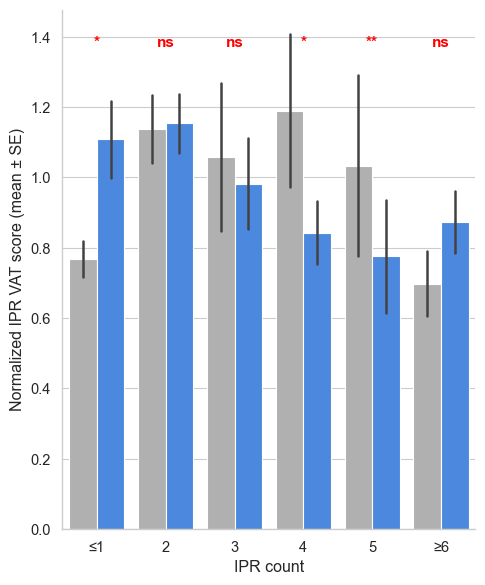

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mannwhitneyu

# 색상 정의
palette = {'Binding': "#3485F6",  # 파랑
           'Not': "#B0B0B0"}  # 회색

plt.figure(figsize=(5,6))
ax = sns.barplot(
    data=DNA_with_means_unique_score_merge_final.drop_duplicates(subset='ENSP_ID'),
    x='IPR_count_bin',
    y='IPR_VAT_score_per_protein',
    hue='Binding',
    estimator=np.mean,
    errorbar='se',        # ✅ SEM으로 지정 (Standard Error of the mean)
    palette=palette,
    alpha=1
)

# --- 각 bin별 Mann–Whitney U test ---
p_values = {}
for bin_label, group_df in DNA_with_means_unique_score_merge_final.groupby('IPR_count_bin'):
    group1 = group_df.loc[group_df['Binding'] == 'Binding', 'IPR_VAT_score_per_protein']
    group0 = group_df.loc[group_df['Binding'] == 'Not', 'IPR_VAT_score_per_protein']
    if len(group1) > 0 and len(group0) > 0:
        stat, p = mannwhitneyu(group1, group0, alternative='two-sided')
        p_values[bin_label] = p
    else:
        p_values[bin_label] = np.nan

# --- p-value를 별표로 변환하는 함수 ---
def p_to_stars(p):
    if np.isnan(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

# 1) 유니코드 대시 통일 함수 (엔대시/엠대시 -> 하이픈)
def norm_dash(s):
    return str(s).replace("–", "-").replace("—", "-").strip()

# 2) 현재 축에서 실제 틱 라벨과 x좌표를 매핑
ax.figure.canvas.draw()  # 최신 라벨 텍스트 반영
tick_labels = [t.get_text() for t in ax.get_xticklabels()]
tick_positions = ax.get_xticks()
tick_map = {norm_dash(lbl): x for lbl, x in zip(tick_labels, tick_positions)}

# 3) p-values 키도 같은 방식으로 정규화
p_values_norm = {norm_dash(k): v for k, v in p_values.items()}

# 4) 각 라벨의 실제 x좌표에 별표 표시
y_top = ax.get_ylim()[1]
for lbl, p in p_values_norm.items():
    if lbl in tick_map:
        stars = p_to_stars(p)
        if stars:
            ax.text(
                tick_map[lbl],
                y_top * 0.95,        # 상단 약간 아래
                stars,
                ha='center', va='top',
                fontsize=11, color='red', fontweight='bold',
                clip_on=False
            )

# 그래프 스타일
ax.set_xlabel("IPR count")
ax.set_ylabel("Normalized IPR VAT score (mean ± SE)")
sns.despine()
plt.tight_layout()

# ✅ 범례 제거
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.show()

In [18]:
from scipy.stats import sem

summary_df = (
    DNA_with_means_unique_score_merge_final
    .groupby(['IPR_count_bin', 'Binding'])['IPR_VAT_score_per_protein']
    .agg(
        mean='mean',
        se=lambda x: sem(x, nan_policy='omit'),
        n='count'
    )
    .reset_index()
)

summary_df

/var/folders/yg/583d6r_n1db_299qvldgw8k00000gn/T/ipykernel_52428/3185445329.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['IPR_count_bin', 'Binding'])['IPR_VAT_score_per_protein']


,IPR_count_bin,Binding,mean,se,n
0,≤1,Binding,1.108892,0.109448,108
1,≤1,Not,0.767478,0.052327,297
2,2,Binding,1.154191,0.059236,162
3,2,Not,1.137459,0.069002,172
4,3,Binding,0.982293,0.074629,117
5,3,Not,1.058168,0.118679,54
6,4,Binding,0.842885,0.043709,104
7,4,Not,1.189234,0.104572,40
8,5,Binding,0.775200,0.070068,70
9,5,Not,1.033208,0.102080,20


In [19]:
DNA_with_means_unique_score_merge_final

,ENSP_ID,Interpro_ID,consensus_start,consensus_end,mean_score_range,IPR_count_per_protein,IPR_VAT_score_per_protein,consensus_length,Seq_length,IPR_proportion,IPR_count_bin,Binding
0,ENSP00000084795,IPR000039,3,189,0.495286,1,0.495286,187,189.0,0.989418,≤1,Not
1,ENSP00000156471,IPR045055,450,982,0.676809,1,0.676809,533,1485.0,0.358923,≤1,Not
2,ENSP00000198939,IPR000061,15,57,2.747430,2,2.117436,43,927.0,0.046386,2,Binding
3,ENSP00000198939,IPR035967,4,67,1.487443,2,2.117436,64,927.0,0.069040,2,Binding
4,ENSP00000199814,IPR000504,234,298,0.652659,2,0.730341,65,420.0,0.154762,2,Binding
...,...,...,...,...,...,...,...,...,...,...,...,...
1408,ENSP00000498157,IPR002415,182,192,1.804225,4,2.285629,11,272.0,0.040441,4,Not
1409,ENSP00000498157,IPR002415,226,238,3.347177,4,2.285629,13,272.0,0.047794,4,Not
1410,ENSP00000498157,IPR050257,151,268,2.163446,4,2.285629,118,272.0,0.433824,4,Not
1411,ENSP00000498177,IPR041988,52,106,1.988236,1,1.988236,55,145.0,0.379310,≤1,Not


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=DNA_with_means_unique_score_merge, x='IPR_count_per_protein', y='mean_score_range', s=5)  # s는 점 크기
sns.regplot(data=DNA_with_means_unique_score_merge, x='IPR_count_per_protein', y='mean_score_range', scatter=False, color='red')  # 점 없이 선만
r = np.corrcoef(DNA_with_means_unique_score_merge['IPR_count_per_protein'], DNA_with_means_unique_score_merge['mean_score_range'])[0,1]
plt.text(DNA_with_means_unique_score_merge['IPR_count_per_protein'].min(), DNA_with_means_unique_score_merge['mean_score_range'].max(), f'r = {r:.2f}', color='black', fontsize=12)

plt.xlabel('IPR_count_per_protein')
plt.ylabel('IPR_VAT_score')
plt.title('Dot Plot (Scatter)')
plt.show()

In [ ]:
sns.scatterplot(data=DNA_with_means_unique_score_merge_drop_dup_byENSPID, x='IPR_count_per_protein', y='IPR_VAT_score_per_protein', s=5)  # s는 점 크기
sns.regplot(data=DNA_with_means_unique_score_merge_drop_dup_byENSPID, x='IPR_count_per_protein', y='IPR_VAT_score_per_protein', scatter=False, color='red')  # 점 없이 선만
r = np.corrcoef(DNA_with_means_unique_score_merge_drop_dup_byENSPID['IPR_count_per_protein'], DNA_with_means_unique_score_merge_drop_dup_byENSPID['IPR_VAT_score_per_protein'])[0,1]
plt.text(DNA_with_means_unique_score_merge_drop_dup_byENSPID['IPR_count_per_protein'].min(), DNA_with_means_unique_score_merge_drop_dup_byENSPID['IPR_VAT_score_per_protein'].max(), f'r = {r:.2f}', color='black', fontsize=12)

plt.xlabel('IPR_count_per_protein')
plt.ylabel('Protein_IPR_mean_VAT_score')
plt.title('Dot Plot (Scatter)')
plt.show()

In [ ]:
sns.scatterplot(data=DNA_with_means_unique_score_merge, x='IPR_count_per_protein', y='consensus_length', s=5)  # s는 점 크기
sns.regplot(data=DNA_with_means_unique_score_merge, x='IPR_count_per_protein', y='consensus_length', scatter=False, color='red')  # 점 없이 선만
r = np.corrcoef(DNA_with_means_unique_score_merge['IPR_count_per_protein'], DNA_with_means_unique_score_merge['consensus_length'])[0,1]
plt.text(DNA_with_means_unique_score_merge['IPR_count_per_protein'].min(), DNA_with_means_unique_score_merge['consensus_length'].max(), f'r = {r:.2f}', color='black', fontsize=12)

plt.xlabel('IPR_count_per_protein')
plt.ylabel('IPR_length')
plt.title('Dot Plot (Scatter)')
plt.show()

In [ ]:
sns.scatterplot(data=DNA_with_means_unique_score_merge, x='consensus_length', y='mean_score_range', s=5)  # s는 점 크기
sns.regplot(data=DNA_with_means_unique_score_merge, x='consensus_length', y='mean_score_range', scatter=False, color='red')  # 점 없이 선만
r = np.corrcoef(DNA_with_means_unique_score_merge['consensus_length'], DNA_with_means_unique_score_merge['mean_score_range'])[0,1]
plt.text(DNA_with_means_unique_score_merge['consensus_length'].min(), DNA_with_means_unique_score_merge['mean_score_range'].max(), f'r = {r:.2f}', color='black', fontsize=12)

plt.xlabel('IPR_length')
plt.ylabel('IPR_VAT_score')
plt.title('Dot Plot (Scatter)')
plt.show()

In [ ]:
ptm = pd.read_csv('/Users/khj/Desktop/Project_ongoing/DRBP/interpret/interproscan/ptm_position.csv')
ptm

In [ ]:
ptm[ptm['Interpro_ID']=='S-Phosphorylation']

In [ ]:
ptm_with_means_DBP = attach_means(DNA_data, ptm)
ptm_with_means_RBP = attach_means(RNA_data, ptm)

ptm_with_means_RBP

In [ ]:
ptm_with_means_DBP.to_csv('/Users/khj/Desktop/Project_ongoing/DRBP/interpret/DBP_PTM_VATP_final.csv',index=None)
ptm_with_means_RBP.to_csv('/Users/khj/Desktop/Project_ongoing/DRBP/interpret/RBP_PTM_VATP_final.csv',index=None)

In [ ]:
ptm_with_means_DBP['IPR_count'] = ptm_with_means_DBP.groupby('Interpro_ID')['Interpro_ID'].transform('count')
ptm_with_means_DBP

In [ ]:
ptm_with_means['IPR_Fold'] = ptm_with_means['mean_score_range'] / ptm_with_means['mean_score_all']
ptm_with_means

In [ ]:
ptm_with_means['IPR_mean_Fold'] = ptm_with_means.groupby('Interpro_ID')['IPR_Fold'].transform('mean')
ptm_with_means

In [ ]:
ptm_with_means_dedup = ptm_with_means.drop_duplicates(subset='Interpro_ID')
ptm_with_means_dedup

In [ ]:
ptm_with_means_dedup[ptm_with_means_dedup['IPR_count']>500].sort_values(by='IPR_mean_Fold',ascending=False)

In [ ]:
ptm_with_means_dedup.sort_values(by='IPR_mean_Fold',ascending=False)

In [ ]:
ptm_with_means_dedup['IPR_mean_Fold'].mean()